<a href="https://colab.research.google.com/github/Rakshitanaik-27/EliteTech-DataScience/blob/main/Task2_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- STEP 1: LOADING & PREPROCESSING DATA ---
Data Loaded Successfully!
Training set: 60000 images | Test set: 10000 images

--- STEP 2: BUILDING CNN MODEL ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)


--- STEP 3: TRAINING MODEL ---
Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 56ms/step - accuracy: 0.7883 - loss: 0.5894 - val_accuracy: 0.8551 - val_loss: 0.3961
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.8625 - loss: 0.3824 - val_accuracy: 0.8749 - val_loss: 0.3499
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.8798 - loss: 0.3357 - val_accuracy: 0.8854 - val_loss: 0.3181
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 54ms/step - accuracy: 0.8899 - loss: 0.3043 - val_accuracy: 0.8941 - val_loss: 0.2922
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 57ms/step - accuracy: 0.8971 - loss: 0.2826 - val_accuracy: 0.8996 - val_loss: 0.2826
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.9051 - loss: 0.2631 - val_accuracy: 0.9020 - val_loss: 0.2774
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 56ms/step - accuracy: 0.9096 - loss: 0.2468 - val_accuracy: 0.9070 - val_loss: 0.2614
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - ac

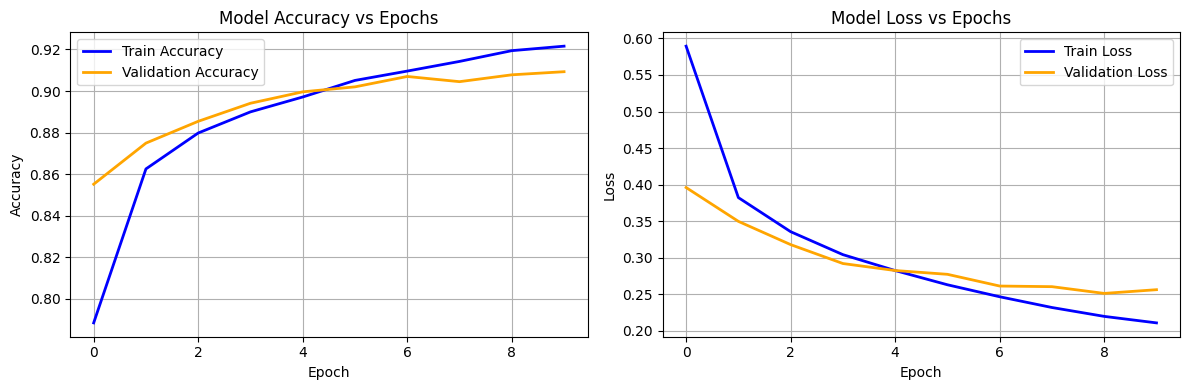


--- STEP 5: VISUALIZING MODEL PREDICTIONS ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


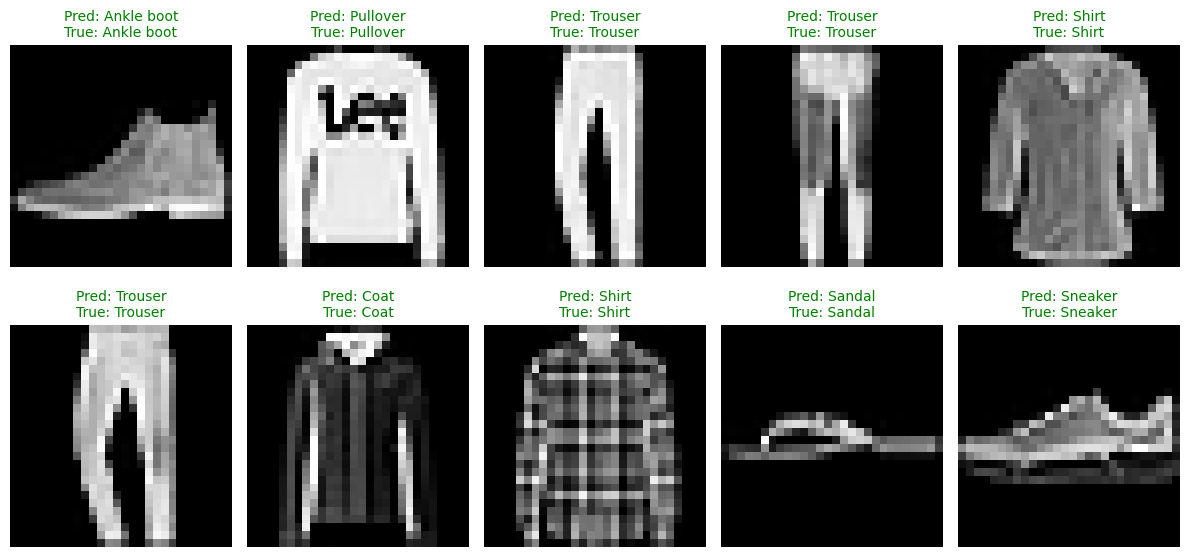

In [2]:
# ==============================================================================
# EliteTech Intern - Task 2: Deep Learning Project
# Purpose: Image Classification using Convolutional Neural Networks (CNN)
# Library: TensorFlow / Keras
# Dataset: Fashion-MNIST (10 Categories of Clothing & Footwear)
# ==============================================================================

import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------------------
# STEP 1: LOAD AND PREPROCESS DATASET
# ------------------------------------------------------------------------------
print("--- STEP 1: LOADING & PREPROCESSING DATA ---")

# Load Fashion-MNIST directly from TensorFlow
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Category names corresponding to target labels 0-9
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Normalize pixel values to range [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape image arrays to include a single color channel (28x28x1)
X_train = X_train.reshape((-1, 28, 28, 1))
X_test = X_test.reshape((-1, 28, 28, 1))

print(f"Data Loaded Successfully!")
print(f"Training set: {X_train.shape[0]} images | Test set: {X_test.shape[0]} images")

# ------------------------------------------------------------------------------
# STEP 2: BUILD CNN ARCHITECTURE
# ------------------------------------------------------------------------------
print("\n--- STEP 2: BUILDING CNN MODEL ---")

model = models.Sequential([
    # Explicit Input Layer (Resolves the Keras 3 UserWarning)
    layers.Input(shape=(28, 28, 1)),

    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Dense Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ------------------------------------------------------------------------------
# STEP 3: TRAIN THE MODEL
# ------------------------------------------------------------------------------
print("\n--- STEP 3: TRAINING MODEL ---")
EPOCHS = 10

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    validation_data=(X_test, y_test),
    batch_size=64
)

# ------------------------------------------------------------------------------
# STEP 4: VISUALIZE TRAINING RESULTS (LOSS & ACCURACY PLOTS)
# ------------------------------------------------------------------------------
print("\n--- STEP 4: VISUALIZING TRAINING METRICS ---")

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss vs Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# STEP 5: VISUALIZE SAMPLE PREDICTIONS
# ------------------------------------------------------------------------------
print("\n--- STEP 5: VISUALIZING MODEL PREDICTIONS ---")

predictions = model.predict(X_test)

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')

    predicted_label = class_names[np.argmax(predictions[i])]
    true_label = class_names[y_test[i]]

    # Green label if prediction is correct, Red if wrong
    color = 'green' if predicted_label == true_label else 'red'

    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()